<a href="https://colab.research.google.com/github/KEERTHANASRI-A-M-0609/keerthanasri-codeboosters-2026/blob/main/Day%202/DAY_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import library

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All Libraries imported Successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.sqlite_version}")

All Libraries imported Successfully!
pandas version: 2.2.2
sqlite3 version: 3.37.2


In [ ]:
#Data sets

df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows")
df.head(3)

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
from sqlite3.dbapi2 import Cursor
#Create Sqlite database and load Student data

conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]
print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has created Successfully!" )


Database 'college.db' created successfully!
Table 'students' has created Successfully!


#                      SQL

select the name and department of students who belong to the Computer Science department

# SELECT name, department
# FROM students
# WHERE department = 'Computer Science';


In [ ]:
query = "SELECT name, department FROM students WHERE department = 'Computer Science';"

df_computer_science = pd.read_sql_query(query, conn)
df_computer_science

,name,department
0,Aarav Sharma,Computer Science
1,Priya Patel,Computer Science
2,Arjun Nair,Computer Science
3,Divya Singh,Computer Science
4,Ananya Das,Computer Science
5,Suresh Rao,Computer Science
6,Ajay Tiwari,Computer Science
7,Swati Kulkarni,Computer Science
8,Nisha Kapoor,Computer Science
9,Tanvi Mehta,Computer Science


In [ ]:
def run_query(sql, description="student"):

  """
  Parameters
  ------------------
  sql : str - The SQL query string to execute
  description : str - A label to print above the results

  Returns:
  -----------------
  Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*55}")
    print(f" {description}")
    print(f"\n{'='*55}")

  result = pd.read_sql_query(sql, conn)

  print(result.to_string(index=False))
  return result

print("Helper fucntion 'run_query' defined successfully")
print("Useage: run_query(sql_string,description_label)")

Helper fucntion 'run_query' defined successfully
Useage: run_query(sql_string,description_label)


In [ ]:
query1=""" select student_id, name, department, math_score, attendance_percentage from students limit
            10
            """

result1= run_query(query1, "Query1: First 10 Students (Select+limit)")


 Query1: First 10 Students (Select+limit)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query1=""" select student_id, name from students limit 5"""

result1= run_query(query1, "Query1: First 5 Students (Select+limit)")


 Query1: First 10 Students (Select+limit)

 student_id         name
       1001 Aarav Sharma
       1002  Priya Patel
       1003  Rohit Verma
       1004  Sneha Reddy
       1005   Arjun Nair


In [ ]:
query2 = """ select name,department,math_score from students order by math_score desc limit 5 """
result2 = run_query(query2, "Query2: Top 5 math scores(ORDER BY DESC + limit)")


 Query2: Top 5 math scores(ORDER BY DESC + limit)

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
#DESCENDING
query3 = """
SELECT name, department, math_score,science_score,programming_score
FROM students
WHERE department = 'Computer Science'
ORDER BY math_score DESC,science_score DESC,programming_Score DESC
LIMIT 10
"""

result3 = run_query(query3, "Query3: Computer Science Students (WHERE filter)")


 Query3: TComputer Science Students (WHERE filter)

          name       department  math_score  science_score  programming_score
    Ananya Das Computer Science          95             89                 97
   Tanvi Mehta Computer Science          93             90                 96
    Arjun Nair Computer Science          92             88                 95
Akanksha Yadav Computer Science          91             93                 94
Swati Kulkarni Computer Science          90             87                 92
   Divya Singh Computer Science          88             91                 93
     Amit Bose Computer Science          86             82                 89
  Aarav Sharma Computer Science          85             78                 91
 Gaurav Shukla Computer Science          84             79                 87
    Suresh Rao Computer Science          83             86                 88


In [ ]:
#ASCENDING
query3 = """
SELECT name, department, math_score,science_Score,programming_score
FROM students
WHERE department = 'Computer Science'
ORDER BY math_score ASC,science_score ASC,programming_Score ASC
LIMIT 10
"""

result3 = run_query(query3, "Query3: Computer Science Students (WHERE filter)")


 Query3: Computer Science Students (WHERE filter)

          name       department  math_score  science_score  programming_score
   Ajay Tiwari Computer Science          71             69                 76
   Priya Patel Computer Science          76             82                 79
  Nisha Kapoor Computer Science          79             84                 83
    Suresh Rao Computer Science          83             86                 88
 Gaurav Shukla Computer Science          84             79                 87
  Aarav Sharma Computer Science          85             78                 91
     Amit Bose Computer Science          86             82                 89
   Divya Singh Computer Science          88             91                 93
Swati Kulkarni Computer Science          90             87                 92
Akanksha Yadav Computer Science          91             93                 94


In [ ]:
query4 = """ SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 90 AND department != 'Civil'
ORDER BY attendance_percentage DESC;
"""

result4 = run_query(query4, "Query4: High Attendance (> 90%) Excluding Civil Dept")


 Query4: High Attendance (> 90%) Excluding Civil Dept

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query4 = """ SELECT name, department, attendance_percentage
FROM students
WHERE attendance_percentage > 93 AND department != 'Mechanical'
ORDER BY attendance_percentage DESC Limit 5;
"""

result4 = run_query(query4, "Query4: High Attendance (> 93%) Excluding Mechanical Dept with Limit 5")


 Query4: High Attendance (> 93%) Excluding Mechanical Dept with Limit 5

          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94


#BETWEEN - Range Filter

Query:
#SELECT name, department,attendance_percentage
#FROM students
# WHERE name BETWEEN 'A' AND 'F';

In [ ]:
query5 = """
SELECT name, department, attendance_percentage
FROM students
WHERE name BETWEEN 'A' AND 'G'
ORDER BY name ASC;
"""

result5 = run_query(query5, "Query5: Students with names between A and F")


 Query5: Students with names between A and F

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Ajay Tiwari Computer Science                     75
Akanksha Yadav Computer Science                     95
     Amit Bose Computer Science                     91
    Ananya Das Computer Science                     98
    Arjun Nair Computer Science                     90
Deepak Chauhan       Mechanical                     77
   Divya Singh Computer Science                     96


# SQL Aggregate Function

Avg()
Count()
sum()

In [41]:
# GROUP BY with aggregate functions
query6 = """
SELECT
    department,
    COUNT(*) AS num_students,
    ROUND(AVG(math_score), 2) AS avg_math,
    ROUND(AVG(science_score), 2) AS avg_science,
    ROUND(AVG(programming_score), 2) AS avg_programming,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""

# SELECT department : the column we are grouping by
# COUNT(*) : count of rows in each group
# AVG(math_score) : average math score for each group
# ROUND(..., 2) : round to 2 decimal places
# AS num_students : 'AS' creates an alias (a readable column name)
# GROUP BY department : Separates students into groups (CS, Electronics, Mechanical, Civil)
# Then calculates COUNT and AVG separately for each group
# Pandas equivalent: df.groupby('department').agg({'math_score':'mean', ...})

result6 = run_query(query6, "Query 6: Department-wise Performance Summary")


 Query 6: Department-wise Performance Summary

      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [42]:
query7="""

select name,attendance_percentage
from students
where attendance_percentage between 80 AND 90
"""
result7=run_query(query7,"Query7: students with attendance between 80 and 90")


 Query6: students with attendance between 80 and 90

         name  attendance_percentage
  Priya Patel                     87
   Arjun Nair                     90
  Kiran Kumar                     85
  Vikram Iyer                     83
  Pooja Gupta                     80
   Suresh Rao                     88
 Nisha Kapoor                     89
Preeti Saxena                     86
   Rekha Nair                     82
Gaurav Shukla                     87
   Nitin Jain                     84


In [38]:
query8="""
select department,
    AVG(math_score) AS avg_math,
    COUNT(*) AS num_students
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
result=run_query(query8,"Query8: Average math score by department")


 Query7: Average math score by department

      department  avg_math  num_students
Computer Science 85.615385            13
      Mechanical 71.000000             6
     Electronics 71.000000             6
           Civil 63.400000             5


In [43]:
#HAVING clause vs WHERE clause
query9 = """
SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math,
    COUNT(*) AS num_students
FROM students
GROUP BY department
HAVING AVG(math_score) > 70
ORDER BY avg_math DESC;
"""

# HAVING AVG(math_score) > 70 : Filters GROUPS (not rows) after GROUP BY
# Only shows departments where the average math score is above 70

# KEY DIFFERENCE:
# WHERE  - filters individual ROWS (applied BEFORE grouping)
# HAVING - filters GROUPS (applied AFTER grouping)

# SQL execution order: FROM -> WHERE -> GROUP BY -> HAVING -> SELECT -> ORDER BY

result8 = run_query(query9, "Query 9: Departments with Average Math Score > 70")


 Query 9: Departments with Average Math Score > 70

      department  avg_math  num_students
Computer Science     85.62            13
      Mechanical     71.00             6
     Electronics     71.00             6


In [44]:
query10="""
 select
     gender,
     COUNT(*) AS num_students,
     ROUND(AVG(math_score), 2) AS avg_math,
     ROUND(AVG(programming_score), 2) AS avg_programming,
     ROUND(AVG(attendance_percentage), 2) AS avg_attendance
from students
group by gender
order by gender
"""
result=run_query(query10,"Query10: Gender-wise performance analysis with additional metrics")


 Query10: Gender-wise performance analysis with additional metrics

gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


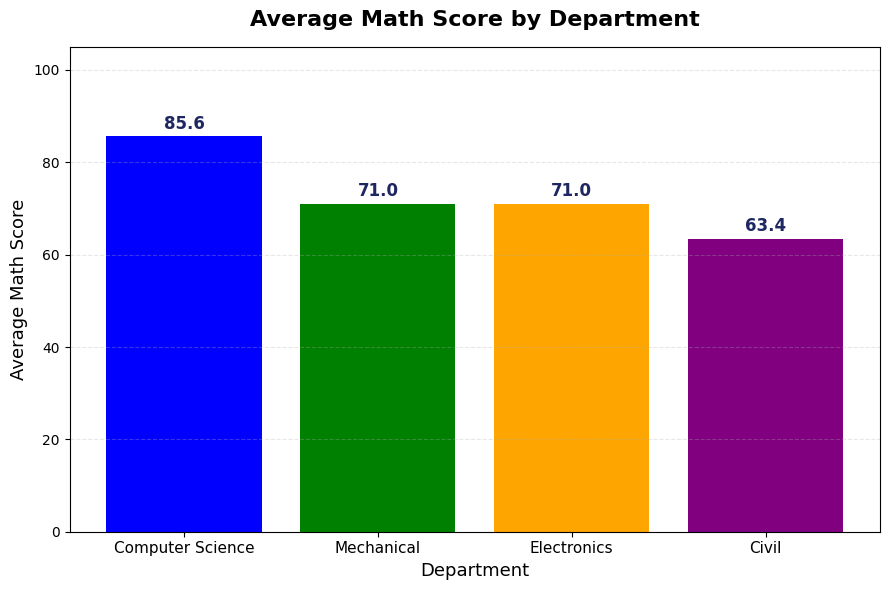

In [51]:
# 1. Use the full summary from Query 6 to include all 4 departments
df_plot = result6

# 2. Define the exact colors for each department
color_map = {
    'Computer Science': 'blue',
    'Mechanical': 'green',
    'Electronics': 'orange',
    'Civil': 'purple'
}

# Map the colors to a list corresponding to the departments in df_plot
bar_colors = df_plot['department'].map(color_map).tolist()

# 3. Initialize the plot and apply the custom colors
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(df_plot['department'], df_plot['avg_math'], color=bar_colors)

# 4. Add value labels ON TOP of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold',
        color='#1E2761'
    )

# 5. Chart styling and adjustments
ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

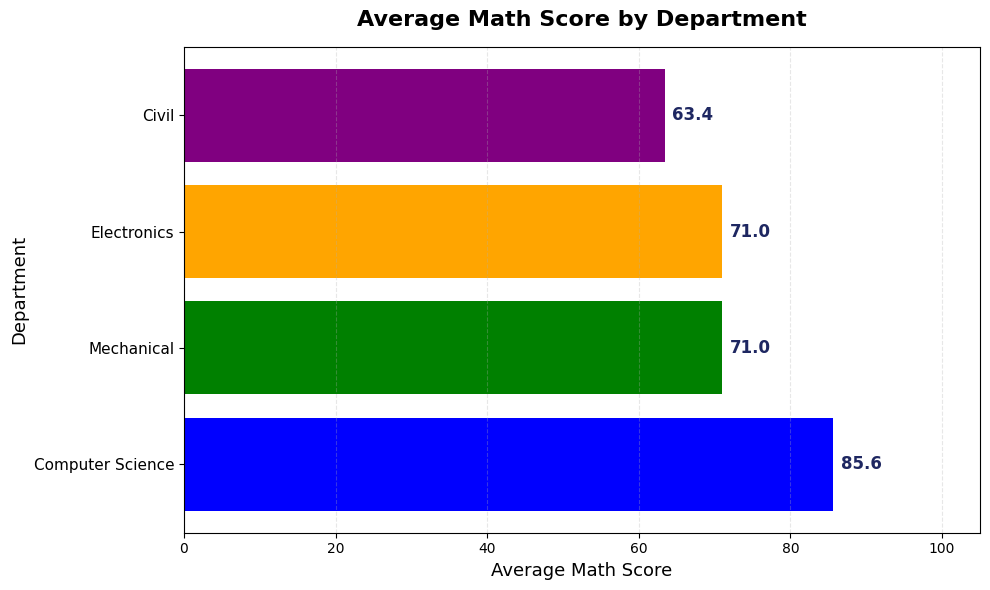

In [52]:
# 1. Use the full summary from Query 6 to include all 4 departments
df_plot = result6

# 2. Define the exact colors for each department
color_map = {
    'Computer Science': 'blue',
    'Mechanical': 'green',
    'Electronics': 'orange',
    'Civil': 'purple'
}
bar_colors = df_plot['department'].map(color_map).tolist()

# 3. Initialize the plot and use barh() for horizontal bars
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_plot['department'], df_plot['avg_math'], color=bar_colors)

# 4. Add value labels to the RIGHT of each horizontal bar
for bar in bars:
    width = bar.get_width()
    # get_width() now gives us the avg_math score for the horizontal bar

    ax.text(
        width + 1.0,                         # x position: just to the right of the bar end
        bar.get_y() + bar.get_height() / 2,  # y position: centered vertically on the bar
        f'{width:.1f}',                      # text: height formatted to 1 decimal place
        ha='left', va='center',              # horizontal/vertical alignment adjusted for side labels
        fontsize=12, fontweight='bold',
        color='#1E2761'
    )

# 5. Chart styling and swapped axis labels
ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Math Score', fontsize=13)  # Swapped to X-axis
ax.set_ylabel('Department', fontsize=13)          # Swapped to Y-axis
ax.set_xlim(0, 105)                               # x-axis limit so labels on the right fit

# Tick and grid customization
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')     # Changed gridlines to vertical (axis='x')

plt.tight_layout()
plt.show()